In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime
from alpha_vantage.fundamentaldata import FundamentalData
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, explained_variance_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

In [152]:
# Your Alpha Vantage API key
api_key = 'E6IM912KFVTJZTEQ'

# Create an Alpha Vantage FundamentalData object
fd = FundamentalData(key=api_key, output_format='pandas')

# Define the stock ticker
ticker = 'AAPL'

# Fetch historical market data (adjusted close prices) for the past 5 years
market_data = yf.download(ticker)

# Fetch historical financial statements
balance_sheet, _ = fd.get_balance_sheet_quarterly(ticker)
income_statement, _ = fd.get_income_statement_quarterly(ticker)
cash_flow, _ = fd.get_cash_flow_quarterly(ticker)

[*********************100%%**********************]  1 of 1 completed


In [153]:
# Define the date range
ticker = 'AAPL'
date_start = pd.to_datetime('2009-06-30')
date_end = pd.to_datetime('2024-07-19')

# Fetch historical market data with actions (splits and dividends)
ticker_obj = yf.Ticker(ticker)
actions = ticker_obj.actions.loc[date_start:date_end]
actions['Stock Splits'] = actions['Stock Splits'].replace(0, np.nan).ffill().fillna(0)
actions.index = pd.to_datetime(actions.index.date)

C:\Users\Taher\AppData\Local\Temp\ipykernel_1580\1322736256.py:8: FutureWarning: Indexing a timezone-aware DatetimeIndex with a timezone-naive datetime is deprecated and will raise KeyError in a future version. Use a timezone-aware object instead.
  actions = ticker_obj.actions.loc[date_start:date_end]


In [154]:
full_date_range = pd.date_range(start=date_start, end=date_end, freq='D')

In [155]:
# Reindex the DataFrame to include all calendar days
actions = actions.reindex(full_date_range)

# Forward fill the stock prices
actions.ffill(inplace=True)
actions.index.name = 'fiscalDateEnding'

# Ensure the index type is datetime
actions.index = pd.to_datetime(actions.index.date)

In [157]:
actions.fillna(1, inplace=True)
actions.replace(0, 1, inplace=True)

In [158]:
df_bs = balance_sheet.copy()
df_is = income_statement.copy()
df_cf = cash_flow.copy()
df_close = market_data[['Adj Close']].copy()

In [145]:
########### Start code from here ###############

In [146]:
with pd.ExcelWriter('Fundamental_data_AAPL.xlsx', engine='openpyxl') as writer:
    # Write each DataFrame to a different sheet
    df_bs.to_excel(writer, sheet_name='Balance Sheet', index=False)
    df_is.to_excel(writer, sheet_name='Income Statement', index=False)
    df_cf.to_excel(writer, sheet_name='Cash Flow Statement', index=False)
    df_close.to_excel(writer, sheet_name='Stock Price', index=False)

In [136]:
file_path = 'Fundamental_data_AAPL.xlsx'
df_bs = pd.read_excel(file_path, sheet_name='Balance Sheet')
df_is = pd.read_excel(file_path, sheet_name='Income Statement')
df_cf = pd.read_excel(file_path, sheet_name='Cash Flow Statement')
df_close = pd.read_excel(file_path, sheet_name='Stock Price')

In [163]:
df_close.reset_index(inplace=True)
df_close.rename(columns={'Adj Close':'Stock Price','Date':'fiscalDateEnding'},inplace=True)

In [164]:
# Convert all values to numeric, coercing errors to NaN
df_bs.iloc[:, 2:] = df_bs.iloc[:, 2:].apply(pd.to_numeric, errors='coerce')
df_is.iloc[:, 2:] = df_is.iloc[:, 2:].apply(pd.to_numeric, errors='coerce')
df_cf.iloc[:, 2:] = df_cf.iloc[:, 2:].apply(pd.to_numeric, errors='coerce')

In [166]:
# Set the index to fiscalDateEnding for each dataframe and ensure no duplicate indices
df_bs = df_bs.set_index(pd.to_datetime(df_bs['fiscalDateEnding'])).drop(df_bs.columns[:2], axis=1)
df_is = df_is.set_index(pd.to_datetime(df_is['fiscalDateEnding'])).drop(df_is.columns[:2], axis=1)
df_cf = df_cf.set_index(pd.to_datetime(df_cf['fiscalDateEnding'])).drop(df_cf.columns[:2], axis=1)
df_close = df_close.set_index('fiscalDateEnding')

In [167]:
# full_date_range = pd.date_range(start=df_close.index.min(), end=df_close.index.max(), freq='D')

# Reindex the DataFrame to include all calendar days
df_close = df_close.reindex(full_date_range)

# Forward fill the stock prices
df_close.ffill(inplace=True)

In [168]:
common_columns_1 = df_bs.columns.intersection(df_is.columns)
common_columns_2 = df_is.columns.intersection(df_cf.columns)
common_columns_3 = df_bs.columns.intersection(df_cf.columns)

In [169]:
common_columns_1,common_columns_2,common_columns_3

(Index([], dtype='object'),
 Index(['netIncome'], dtype='object'),
 Index([], dtype='object'))

In [170]:
df_cf.drop(columns = {'netIncome'},inplace=True)

In [171]:
# Merge market data with financial statements
financial_data = pd.merge(pd.merge(df_bs, df_is, left_index=True, right_index=True,how='outer'), df_cf, left_index=True, right_index=True,how='outer')
financial_data = financial_data.merge(df_close,left_index=True, right_index=True,how='left')
financial_data = financial_data.merge(actions,left_index=True, right_index=True,how='left')

In [172]:
# financial_data.to_csv('financial_data.csv')

In [173]:
# Calculate financial ratios for each quarter
def calculate_ratios(df):
    df['Current Ratio'] = df['totalCurrentAssets'] / df['totalCurrentLiabilities']
    df['Quick Ratio'] = (df['totalCurrentAssets'] - df['inventory']) / df['totalCurrentLiabilities']
    df['Debt-to-Equity Ratio'] = df['totalLiabilities'] / df['totalShareholderEquity']
    df['Working Capital'] = df['totalCurrentAssets'] - df['totalCurrentLiabilities']
    #df['Book Value per Share'] = (df['totalShareholderEquity'] - df.get('preferredStock', 0)) / df['commonStockSharesOutstanding']
    df['Book Value per Share'] = ((df['totalShareholderEquity']) / df['commonStockSharesOutstanding'])  
    
    df['Net Profit Margin'] = (df['netIncome'] / df['totalRevenue']) * 100
    df['Gross Margin'] = (df['grossProfit'] / df['totalRevenue']) * 100
    df['Operating Margin'] = (df['operatingIncome'] / df['totalRevenue']) * 100
    #df['EPS'] = ((df['netIncome'] - df.get('preferredDividends', 0)) / df['commonStockSharesOutstanding'])
    df['EPS'] = ((df['netIncome']) / df['commonStockSharesOutstanding'])
    df['ROE'] = (df['netIncome'] / df['totalShareholderEquity']) * 100
    
    df['Operating Cash Flow Ratio'] = df['operatingCashflow'] / df['totalCurrentLiabilities']
    df['Free Cash Flow'] = df['operatingCashflow'] - df['capitalExpenditures']
    df['Cash Flow Margin'] = (df['operatingCashflow'] / df['totalRevenue']) * 100
    df['Capex Ratio'] = df['operatingCashflow'] / df['capitalExpenditures']
    df['Cash ROA'] = (df['operatingCashflow'] / df['totalAssets']) * 100

    return df

# Apply the function to calculate ratios
df_ratios = calculate_ratios(financial_data)

# Store the results in a DataFrame
df_ratios = df_ratios[['Current Ratio', 'Quick Ratio', 'Debt-to-Equity Ratio', 'Working Capital', 'Book Value per Share',
                                   'Net Profit Margin', 'Gross Margin', 'Operating Margin', 'EPS', 'ROE',
                                   'Operating Cash Flow Ratio', 'Free Cash Flow', 'Cash Flow Margin', 'Capex Ratio', 'Cash ROA','Stock Price']]

In [223]:
# Save the DataFrame to a CSV file
df = df_ratios.iloc[5:].copy()
df = df.astype(float)

In [226]:
# df.to_csv('financial_ratios_quarterly_v3.csv')

In [232]:
# Calculate rolling averages and lags for each feature
for feature in features:
    df[f'{feature}_rolling_avg'] = df[feature].rolling(window=3).mean()
    for lag in range(1, 6):
        df[f'{feature}_lag_{lag}'] = df[feature].shift(lag)

df

,Current Ratio,Quick Ratio,Debt-to-Equity Ratio,Working Capital,Book Value per Share,Net Profit Margin,Gross Margin,Operating Margin,EPS,ROE,...,Capex Ratio_lag_2,Capex Ratio_lag_3,Capex Ratio_lag_4,Capex Ratio_lag_5,Cash ROA_rolling_avg,Cash ROA_lag_1,Cash ROA_lag_2,Cash ROA_lag_3,Cash ROA_lag_4,Cash ROA_lag_5
2009-09-30,2.742482,2.702938,0.501296,2.004900e+10,35.163155,20.742197,41.820267,30.179405,2.813941,8.002528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-12-31,2.545010,2.501031,0.507660,2.023500e+10,39.466736,21.539246,40.878658,30.128164,3.727316,9.444196,...,NaN,NaN,NaN,NaN,NaN,6.547231,NaN,NaN,NaN,NaN
2010-03-31,2.644206,2.592035,0.450061,2.010700e+10,43.256872,22.772057,41.669753,29.476258,3.379374,7.812341,...,6.775599,NaN,NaN,NaN,7.117038,10.720246,6.547231,NaN,NaN,NaN
2010-06-30,2.308032,2.247694,0.501357,2.042100e+10,47.194125,20.719745,39.082803,26.968153,3.561098,7.545638,...,15.375000,6.775599,NaN,NaN,7.407139,4.083636,10.720246,6.547231,NaN,NaN
2010-09-30,2.011292,1.960573,0.573162,2.095600e+10,52.175287,21.176818,36.926707,26.775795,4.703211,9.014250,...,8.503650,15.375000,6.775599,NaN,6.353354,7.417536,4.083636,10.720246,6.547231,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-30,0.981563,0.922737,4.558582,-2.304000e+09,3.851899,24.605503,45.066152,28.463224,1.270525,32.984371,...,9.794239,8.979403,7.335664,10.890580,8.356755,8.598266,8.598266,9.806862,6.839591,6.806835
2023-09-30,0.988012,0.944442,4.673462,-1.742000e+09,3.996512,25.940155,45.682291,30.474824,1.476264,36.938821,...,9.794239,9.794239,8.979403,7.335664,7.532550,7.873734,8.598266,8.598266,9.806862,6.839591
2023-12-31,1.072544,1.023945,3.770769,9.719000e+09,4.792945,28.363788,45.874974,33.763747,2.193759,45.770580,...,12.603918,9.794239,9.794239,8.979403,8.428217,6.125650,7.873734,8.598266,8.598266,9.806862
2024-03-31,1.037102,0.986771,3.547686,4.594000e+09,4.837366,26.044318,46.578075,30.742785,1.541041,31.857023,...,9.985206,12.603918,9.794239,9.794239,8.045218,11.285267,6.125650,7.873734,8.598266,8.598266


In [233]:
df.dropna(inplace=True)

In [235]:
df

,Current Ratio,Quick Ratio,Debt-to-Equity Ratio,Working Capital,Book Value per Share,Net Profit Margin,Gross Margin,Operating Margin,EPS,ROE,...,Capex Ratio_lag_2,Capex Ratio_lag_3,Capex Ratio_lag_4,Capex Ratio_lag_5,Cash ROA_rolling_avg,Cash ROA_lag_1,Cash ROA_lag_2,Cash ROA_lag_3,Cash ROA_lag_4,Cash ROA_lag_5
2010-12-31,1.846060,1.808867,0.586763,2.013200e+10,59.352763,22.452414,38.510153,29.269661,6.518750,10.983061,...,8.068908,8.503650,15.375000,6.775599,8.747723,7.558890,7.417536,4.083636,10.720246,6.547231
2011-03-31,1.931886,1.893657,0.543732,2.267000e+10,66.485047,24.231018,41.355027,31.868221,6.474714,9.738601,...,7.477632,8.068908,8.503650,15.375000,8.459524,11.266745,7.558890,7.417536,4.083636,10.720246
2011-06-30,1.746081,1.712983,0.539564,2.003900e+10,74.811433,25.578384,41.727626,32.826992,7.884314,10.538915,...,8.050247,7.477632,8.068908,8.503650,9.408175,6.552938,11.266745,7.558890,7.417536,4.083636
2011-09-30,1.608438,1.580694,0.518906,1.701800e+10,82.445815,23.427662,40.254687,30.810046,7.127046,8.644521,...,9.966346,8.050247,7.477632,8.068908,8.639878,10.404841,6.552938,11.266745,7.558890,7.417536
2011-12-31,1.582657,1.546941,0.539976,2.016400e+10,96.602282,28.195886,44.683055,37.424730,14.013950,14.506851,...,14.296010,9.966346,8.050247,7.477632,10.674841,8.961855,10.404841,6.552938,11.266745,7.558890
2012-03-31,1.582969,1.548570,0.472556,1.867600e+10,109.625640,29.658552,47.374062,39.258919,12.430186,11.338758,...,6.339818,14.296010,9.966346,8.050247,10.293340,12.657826,8.961855,10.404841,6.552938,11.266745
2012-06-30,1.571174,1.537235,0.457735,1.888300e+10,119.225492,25.194872,42.811866,33.044000,9.414617,7.896480,...,13.288418,6.339818,14.296010,9.966346,9.391025,9.260339,12.657826,8.961855,10.404841,6.552938
2012-09-30,1.495849,1.475326,0.489417,1.911100e+10,125.861364,22.863260,40.040594,30.428738,8.755249,6.956264,...,9.592999,13.288418,6.339818,14.296010,6.901424,6.254911,9.260339,12.657826,8.961855,10.404841
2012-12-31,1.543292,1.512255,0.539805,2.546900e+10,135.622643,23.991048,38.633695,31.571030,13.927983,10.269659,...,4.955739,9.592999,13.288418,6.339818,7.796870,5.189022,6.254911,9.260339,12.657826,8.961855
2013-03-31,1.783739,1.748676,0.437324,2.782900e+10,144.123885,21.895282,37.495126,28.800771,10.155367,7.046276,...,2.639700,4.955739,9.592999,13.288418,7.852156,11.946677,5.189022,6.254911,9.260339,12.657826


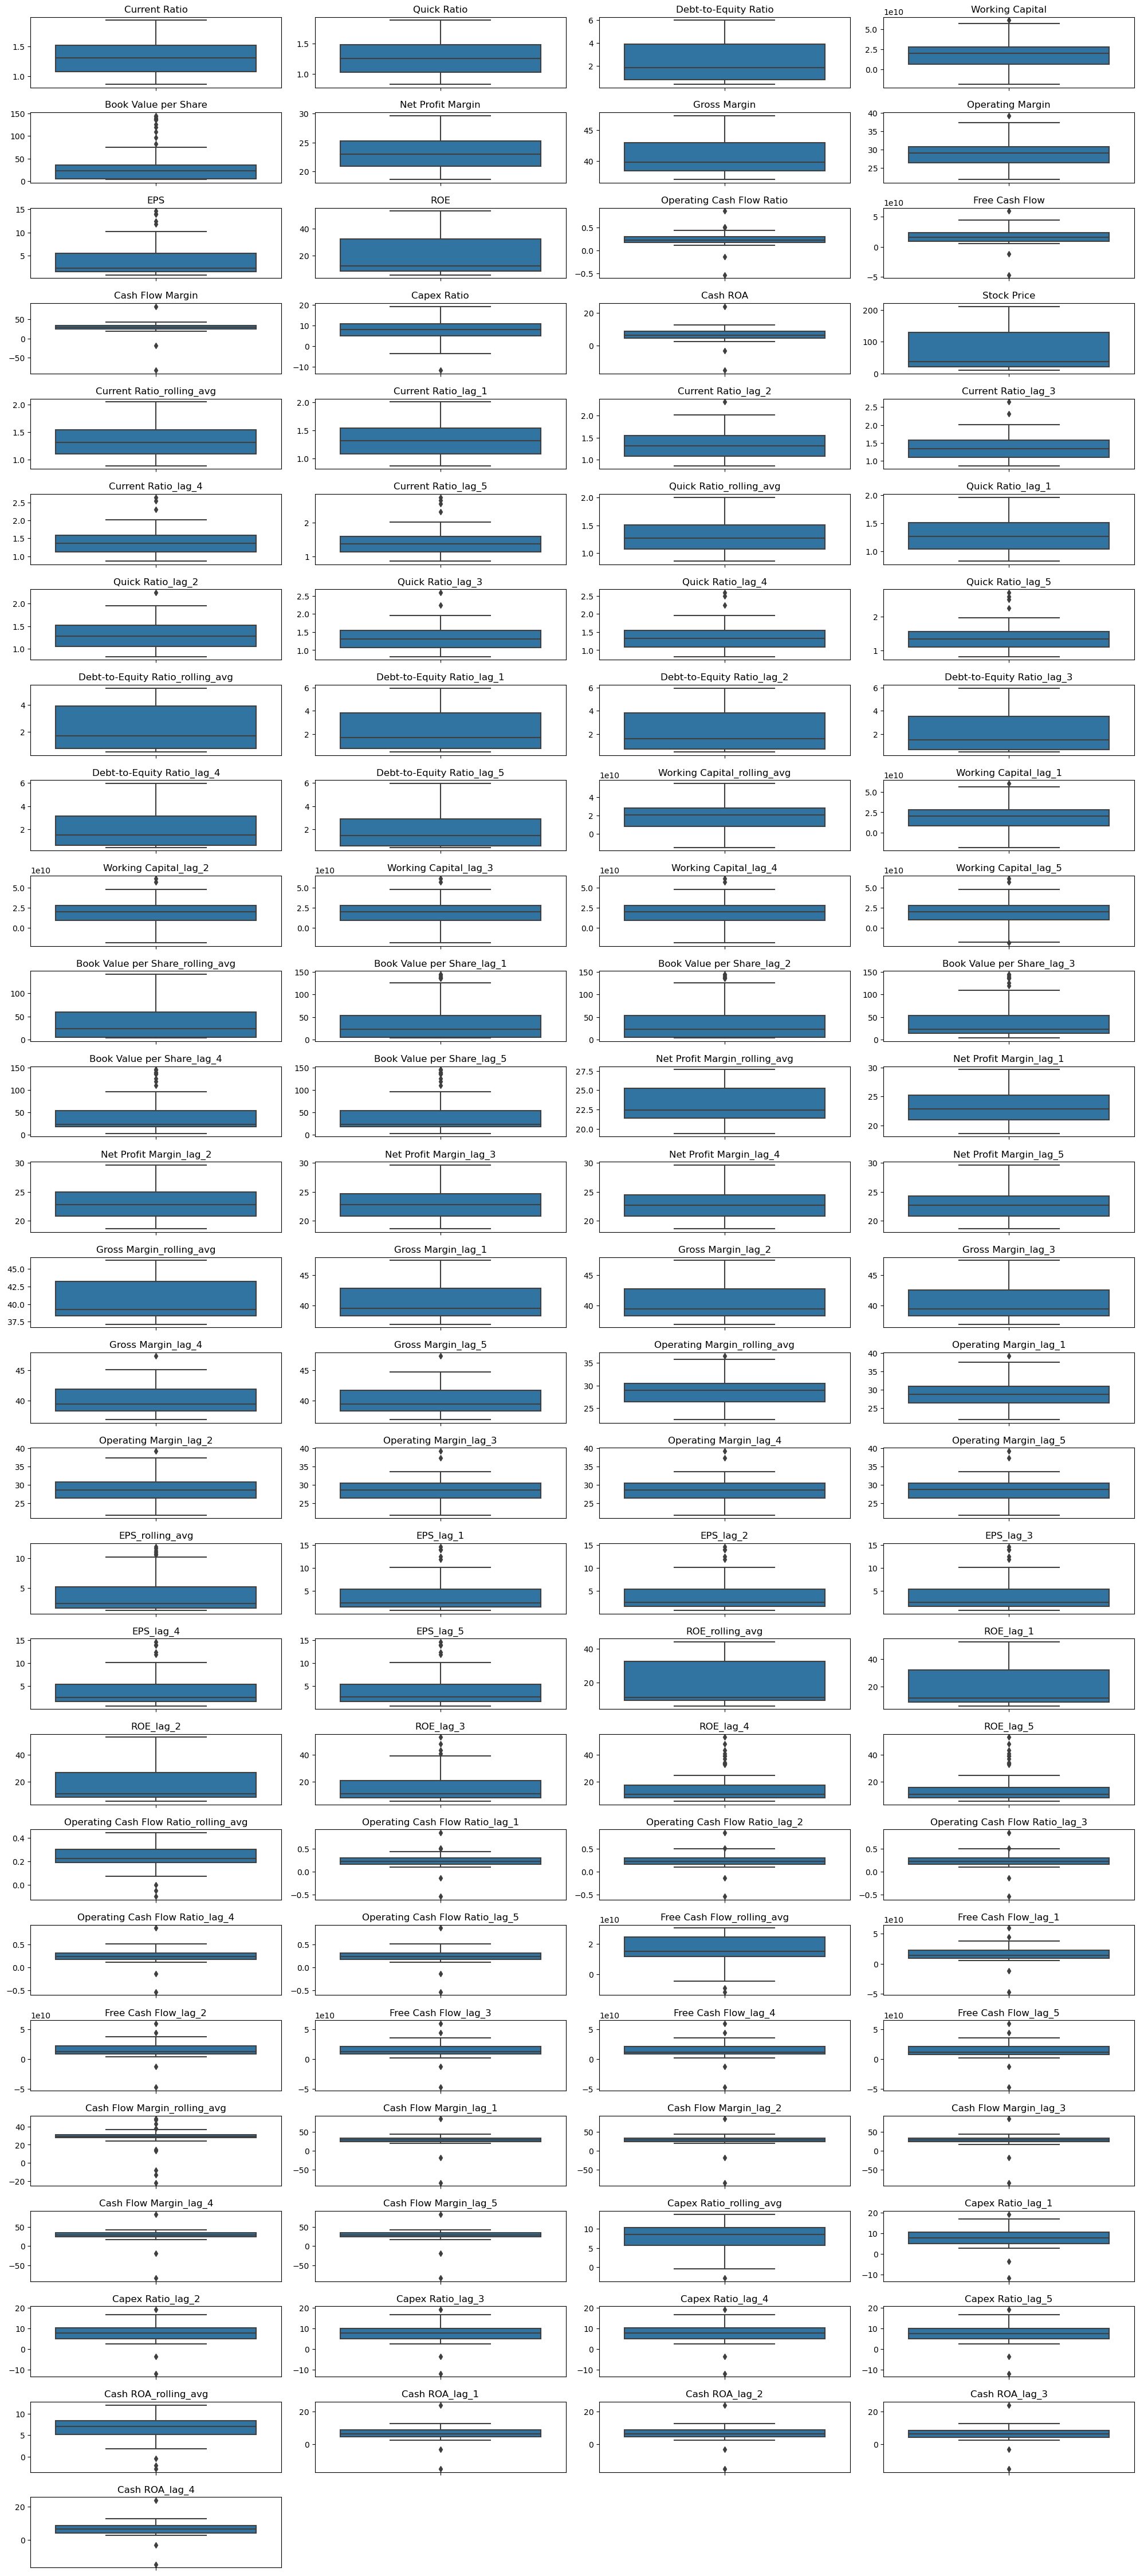

In [240]:
####### FEATURE ANALYSIS #############
features = df.columns[:-1]

# Box plots to check for outliers

plt.figure(figsize=(20, 50))

# Create a grid of box plots for key metrics
for i, metric in enumerate(features, 1):
    plt.subplot(30, 4, i)
    sns.boxplot(data=df, y=metric)
    plt.title(metric)
    plt.xlabel('')
    plt.ylabel('')

# Adjust the layout
plt.tight_layout()

# Show the plots
plt.show()

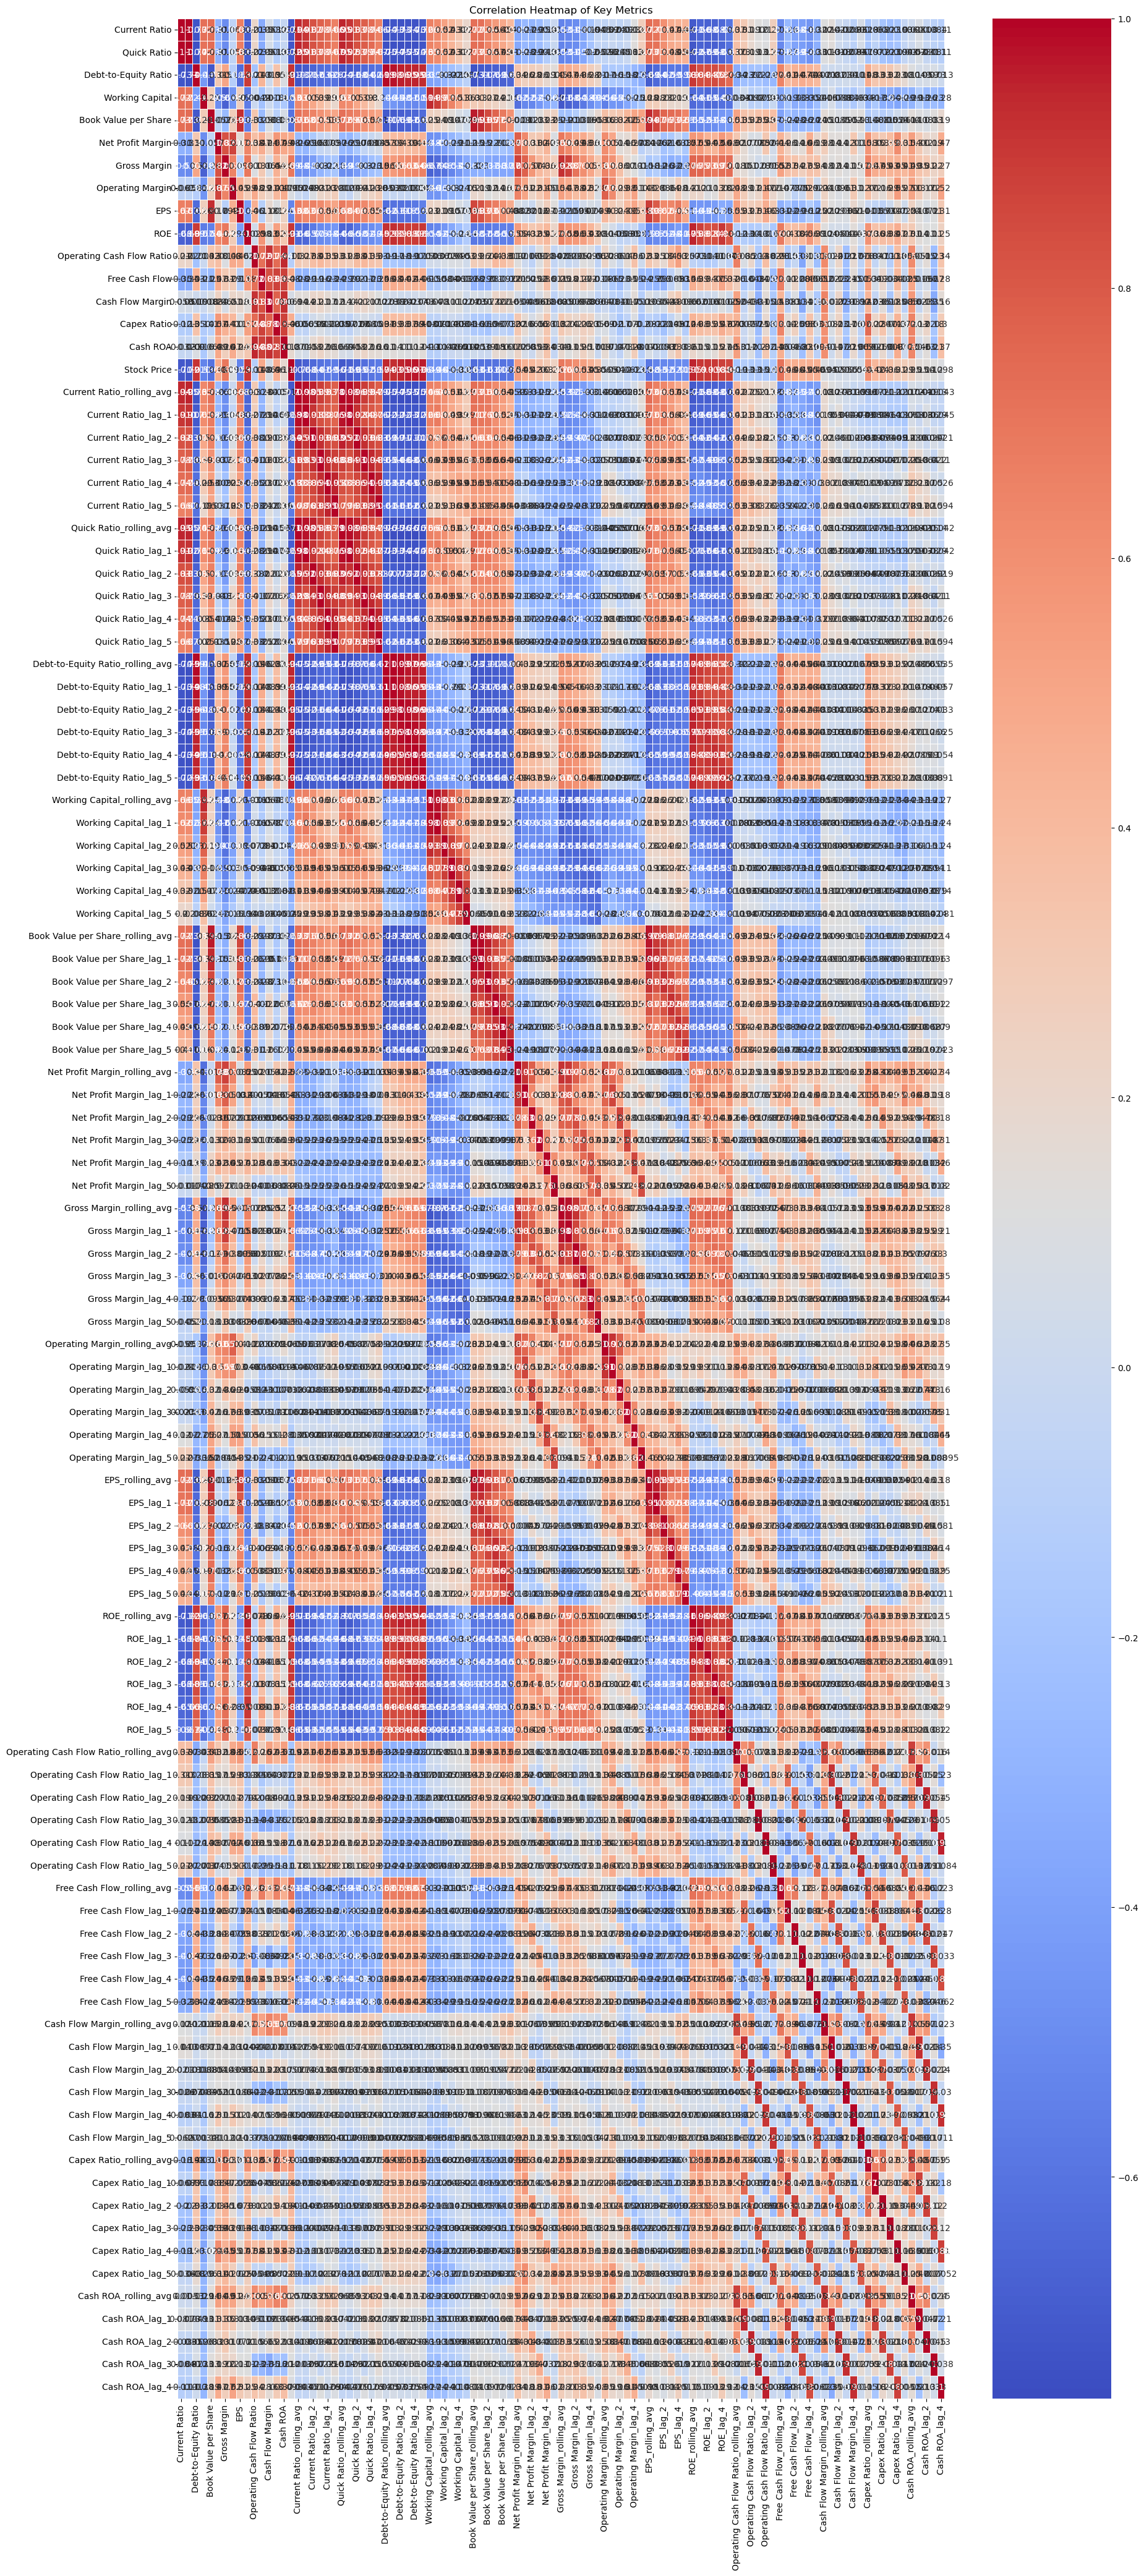

In [241]:
# correlation heatmap

correlation_matrix = df[features].corr()

# Set the size of the figure
plt.figure(figsize=(20, 50))

# Create a heatmap for the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Key Metrics')
plt.show()

In [277]:
least_correlated_pairs = correlation_matrix.unstack().sort_values().drop_duplicates()
least_correlated_pairs = least_correlated_pairs[least_correlated_pairs != 1].tail(10)
least_correlated_pairs

Debt-to-Equity Ratio        Debt-to-Equity Ratio_rolling_avg    0.987481
Debt-to-Equity Ratio_lag_2  Debt-to-Equity Ratio_rolling_avg    0.987721
Debt-to-Equity Ratio_lag_1  Debt-to-Equity Ratio_rolling_avg    0.995653
Current Ratio               Quick Ratio                         0.999271
Current Ratio_lag_1         Quick Ratio_lag_1                   0.999297
Quick Ratio_lag_2           Current Ratio_lag_2                 0.999354
Quick Ratio_lag_3           Current Ratio_lag_3                 0.999486
Quick Ratio_lag_4           Current Ratio_lag_4                 0.999558
Quick Ratio_rolling_avg     Current Ratio_rolling_avg           0.999567
Quick Ratio_lag_5           Current Ratio_lag_5                 0.999644
dtype: float64

## Adding more features like M2 money supply and 10 Y - 3 month interest rate spread

In [242]:
df_treasury_spread = pd.read_csv('T10Y3M.csv')
df_money_supply = pd.read_csv('M2SL.csv')

In [243]:
df_treasury_spread['DATE']=pd.to_datetime(df_treasury_spread['DATE'])
df_money_supply['DATE']=pd.to_datetime(df_money_supply['DATE'])

# Replace non-numeric values (such as '.') with NaN
df_treasury_spread['T10Y3M'] = df_treasury_spread['T10Y3M'].replace('.', np.nan)
df_treasury_spread['T10Y3M'] = df_treasury_spread['T10Y3M'].astype(float)

df_treasury_spread.set_index('DATE',inplace=True)
df_money_supply.set_index('DATE',inplace=True)

In [244]:
df_treasury_spread = df_treasury_spread.reindex(full_date_range)
df_money_supply = df_money_supply.reindex(full_date_range)

In [245]:
# Forward fill the stock prices
df_treasury_spread.ffill(inplace=True)
df_money_supply.ffill(inplace=True)

df_treasury_spread.index.name = 'DATE'
df_money_supply.index.name = 'DATE'

# Ensure the index type is datetime
df_treasury_spread.index = pd.to_datetime(df_treasury_spread.index)
df_money_supply.index = pd.to_datetime(df_money_supply.index)

In [246]:
df.index.name = 'DATE'

In [286]:
### merge these dataframes on the stock data ####

df_new = pd.merge(df,df_treasury_spread,on='DATE',how='left')
df_final = pd.merge(df_new,df_money_supply,on='DATE',how='left')

,Current Ratio,Quick Ratio,Debt-to-Equity Ratio,Working Capital,Book Value per Share,Net Profit Margin,Gross Margin,Operating Margin,EPS,ROE,...,Capex Ratio_lag_4,Capex Ratio_lag_5,Cash ROA_rolling_avg,Cash ROA_lag_1,Cash ROA_lag_2,Cash ROA_lag_3,Cash ROA_lag_4,Cash ROA_lag_5,T10Y3M,M2SL
DATE,,,,,,,,,,,,,,,,,,,,,
2010-12-31,1.846060,1.808867,0.586763,2.013200e+10,59.352763,22.452414,38.510153,29.269661,6.518750,10.983061,...,15.375000,6.775599,8.747723,7.558890,7.417536,4.083636,10.720246,6.547231,3.18,8801.8
2011-03-31,1.931886,1.893657,0.543732,2.267000e+10,66.485047,24.231018,41.355027,31.868221,6.474714,9.738601,...,8.503650,15.375000,8.459524,11.266745,7.558890,7.417536,4.083636,10.720246,3.38,8943.5
2011-06-30,1.746081,1.712983,0.539564,2.003900e+10,74.811433,25.578384,41.727626,32.826992,7.884314,10.538915,...,8.068908,8.503650,9.408175,6.552938,11.266745,7.558890,7.417536,4.083636,3.15,9151.0
2011-09-30,1.608438,1.580694,0.518906,1.701800e+10,82.445815,23.427662,40.254687,30.810046,7.127046,8.644521,...,7.477632,8.068908,8.639878,10.404841,6.552938,11.266745,7.558890,7.417536,1.90,9528.3
2011-12-31,1.582657,1.546941,0.539976,2.016400e+10,96.602282,28.195886,44.683055,37.424730,14.013950,14.506851,...,8.050247,7.477632,10.674841,8.961855,10.404841,6.552938,11.266745,7.558890,1.87,9660.1
2012-03-31,1.582969,1.548570,0.472556,1.867600e+10,109.625640,29.658552,47.374062,39.258919,12.430186,11.338758,...,9.966346,8.050247,10.293340,12.657826,8.961855,10.404841,6.552938,11.266745,2.16,9830.6
2012-06-30,1.571174,1.537235,0.457735,1.888300e+10,119.225492,25.194872,42.811866,33.044000,9.414617,7.896480,...,14.296010,9.966346,9.391025,9.260339,12.657826,8.961855,10.404841,6.552938,1.58,9999.3
2012-09-30,1.495849,1.475326,0.489417,1.911100e+10,125.861364,22.863260,40.040594,30.428738,8.755249,6.956264,...,6.339818,14.296010,6.901424,6.254911,9.260339,12.657826,8.961855,10.404841,1.55,10200.8
2012-12-31,1.543292,1.512255,0.539805,2.546900e+10,135.622643,23.991048,38.633695,31.571030,13.927983,10.269659,...,13.288418,6.339818,7.796870,5.189022,6.254911,9.260339,12.657826,8.961855,1.73,10459.7


Mean Squared Error: 138.8357420185458
                            Feature  Importance
2              Debt-to-Equity Ratio    0.608232
44       Book Value per Share_lag_5    0.289589
13                      Capex Ratio    0.021144
6                      Gross Margin    0.017011
29       Debt-to-Equity Ratio_lag_2    0.011684
..                              ...         ...
22                Quick Ratio_lag_1    0.000000
77  Operating Cash Flow Ratio_lag_2    0.000000
80  Operating Cash Flow Ratio_lag_5    0.000000
83             Free Cash Flow_lag_2    0.000000
53               Gross Margin_lag_2    0.000000

[107 rows x 2 columns]


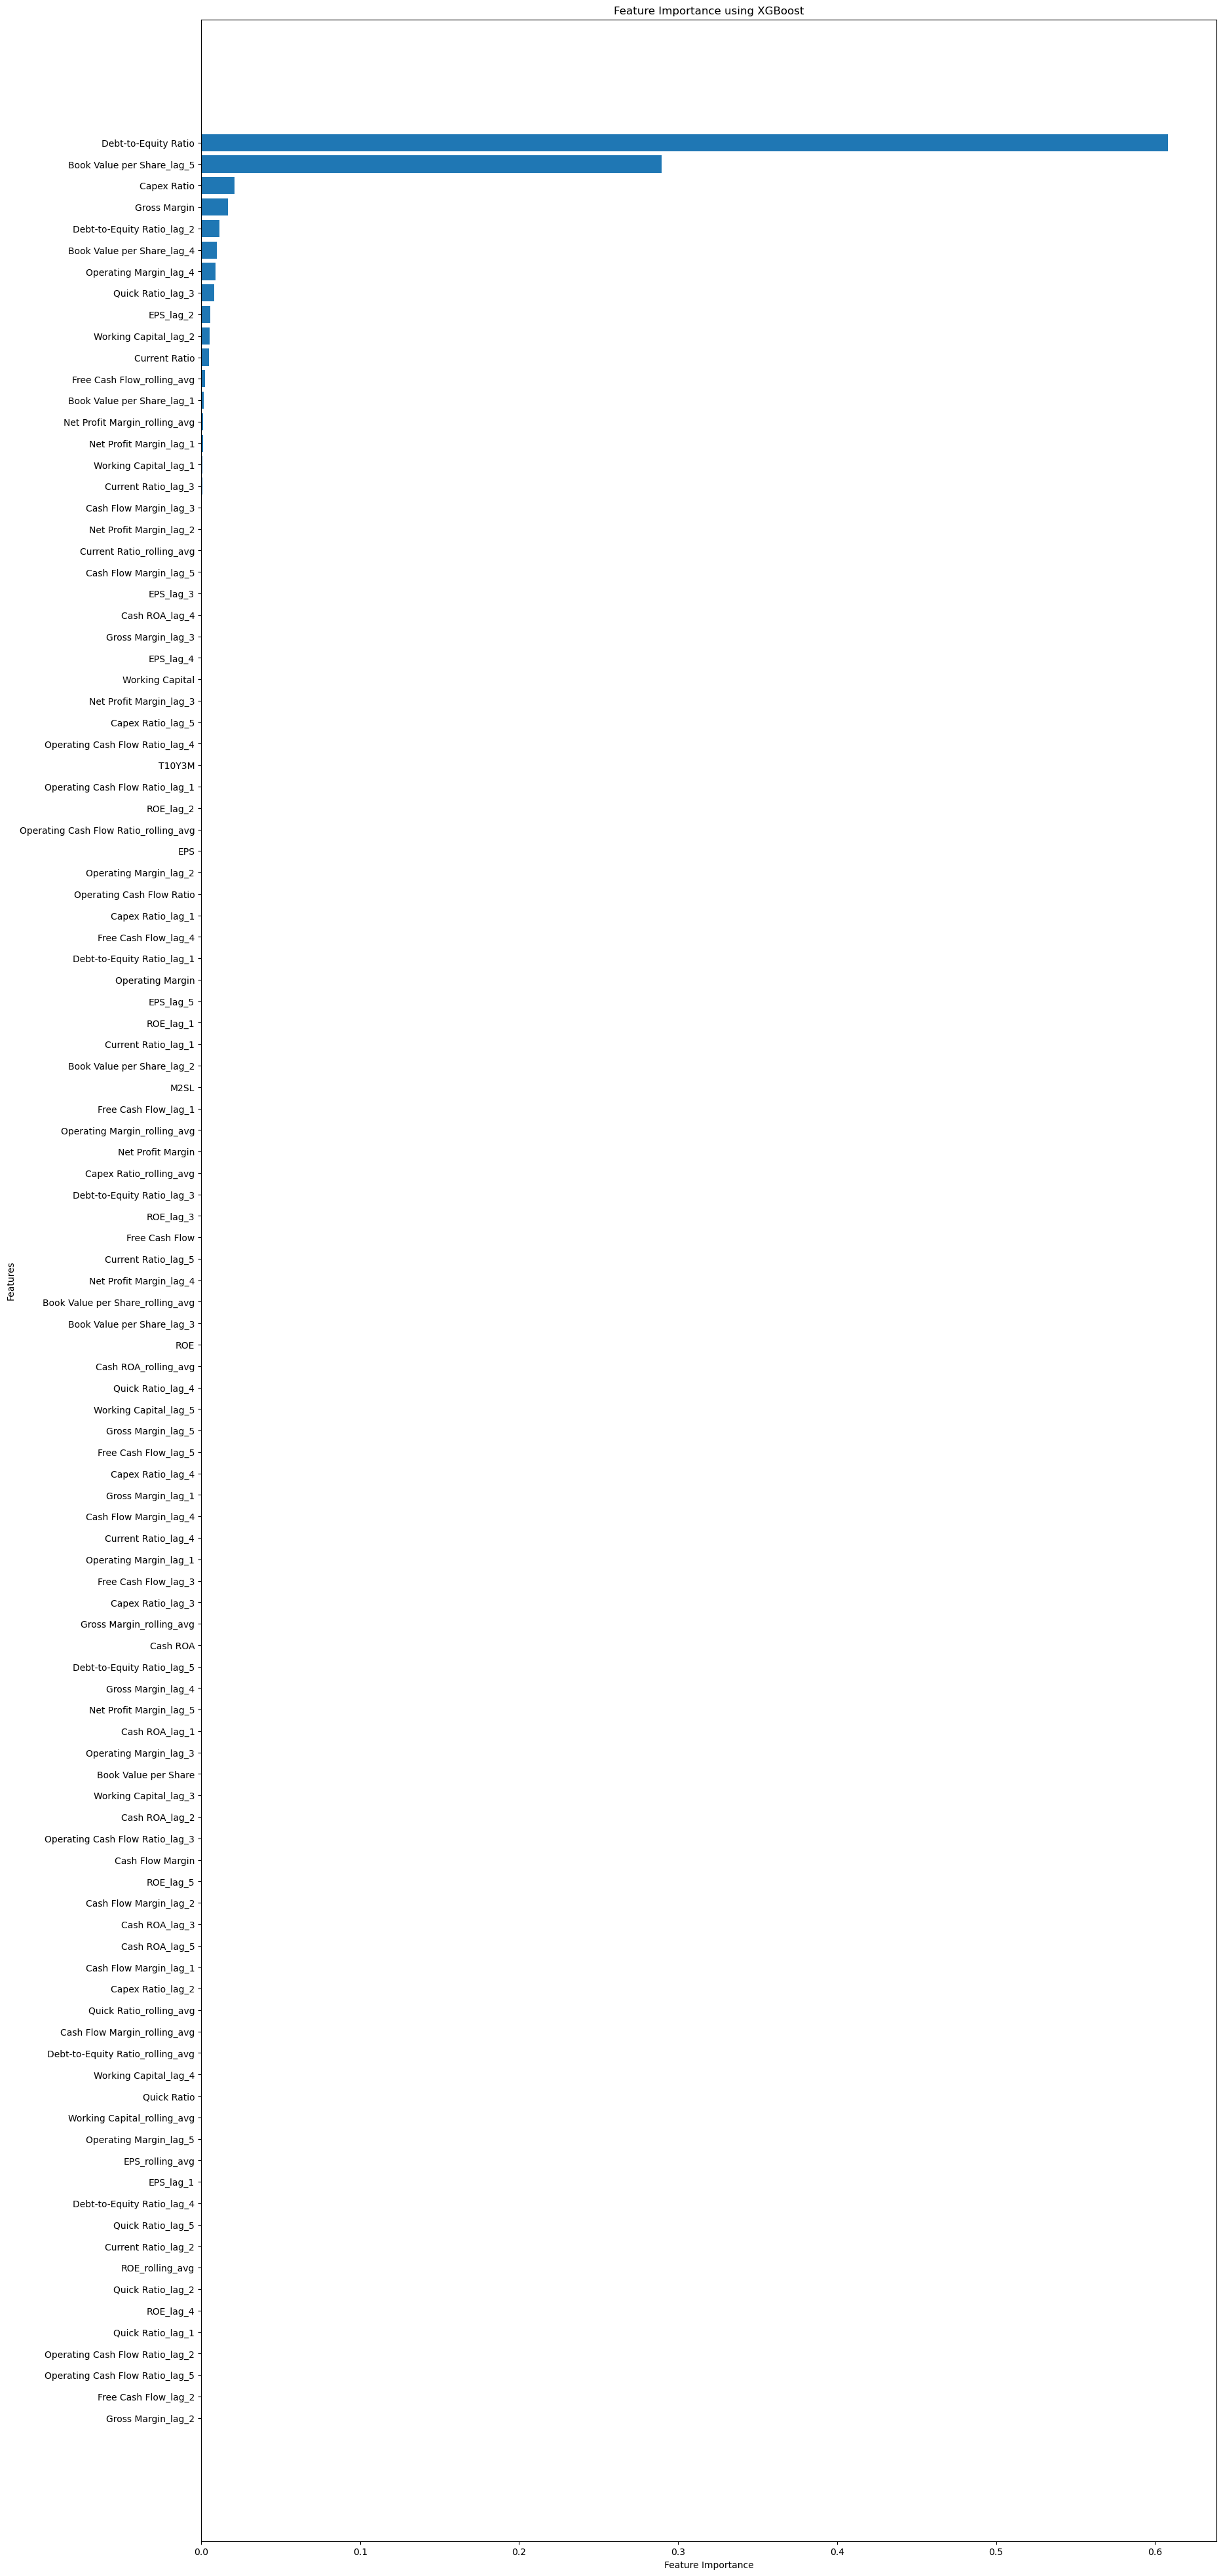

In [287]:
#### Feature importance #####

X = df_final.drop('Stock Price', axis=1)  # Replace 'target' with your target column name
y = df_final['Stock Price']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = xgb.XGBRegressor(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate feature importance
importance = model.feature_importances_

# Convert to DataFrame for better readability
importance_df_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(importance_df_xgb)

# Plot feature importance
plt.figure(figsize=(20, 50))
plt.barh(importance_df_xgb['Feature'], importance_df_xgb['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance using XGBoost')
plt.gca().invert_yaxis()
plt.show()

Mean Squared Error: 75.29655018688568
                                   Feature  Importance
32              Debt-to-Equity Ratio_lag_5    0.094746
9                                      ROE    0.088227
30              Debt-to-Equity Ratio_lag_3    0.073145
31              Debt-to-Equity Ratio_lag_4    0.066014
106                                   M2SL    0.065862
..                                     ...         ...
96                       Capex Ratio_lag_3    0.000033
48                 Net Profit Margin_lag_3    0.000031
75   Operating Cash Flow Ratio_rolling_avg    0.000026
80         Operating Cash Flow Ratio_lag_5    0.000014
60                  Operating Margin_lag_3    0.000014

[107 rows x 2 columns]


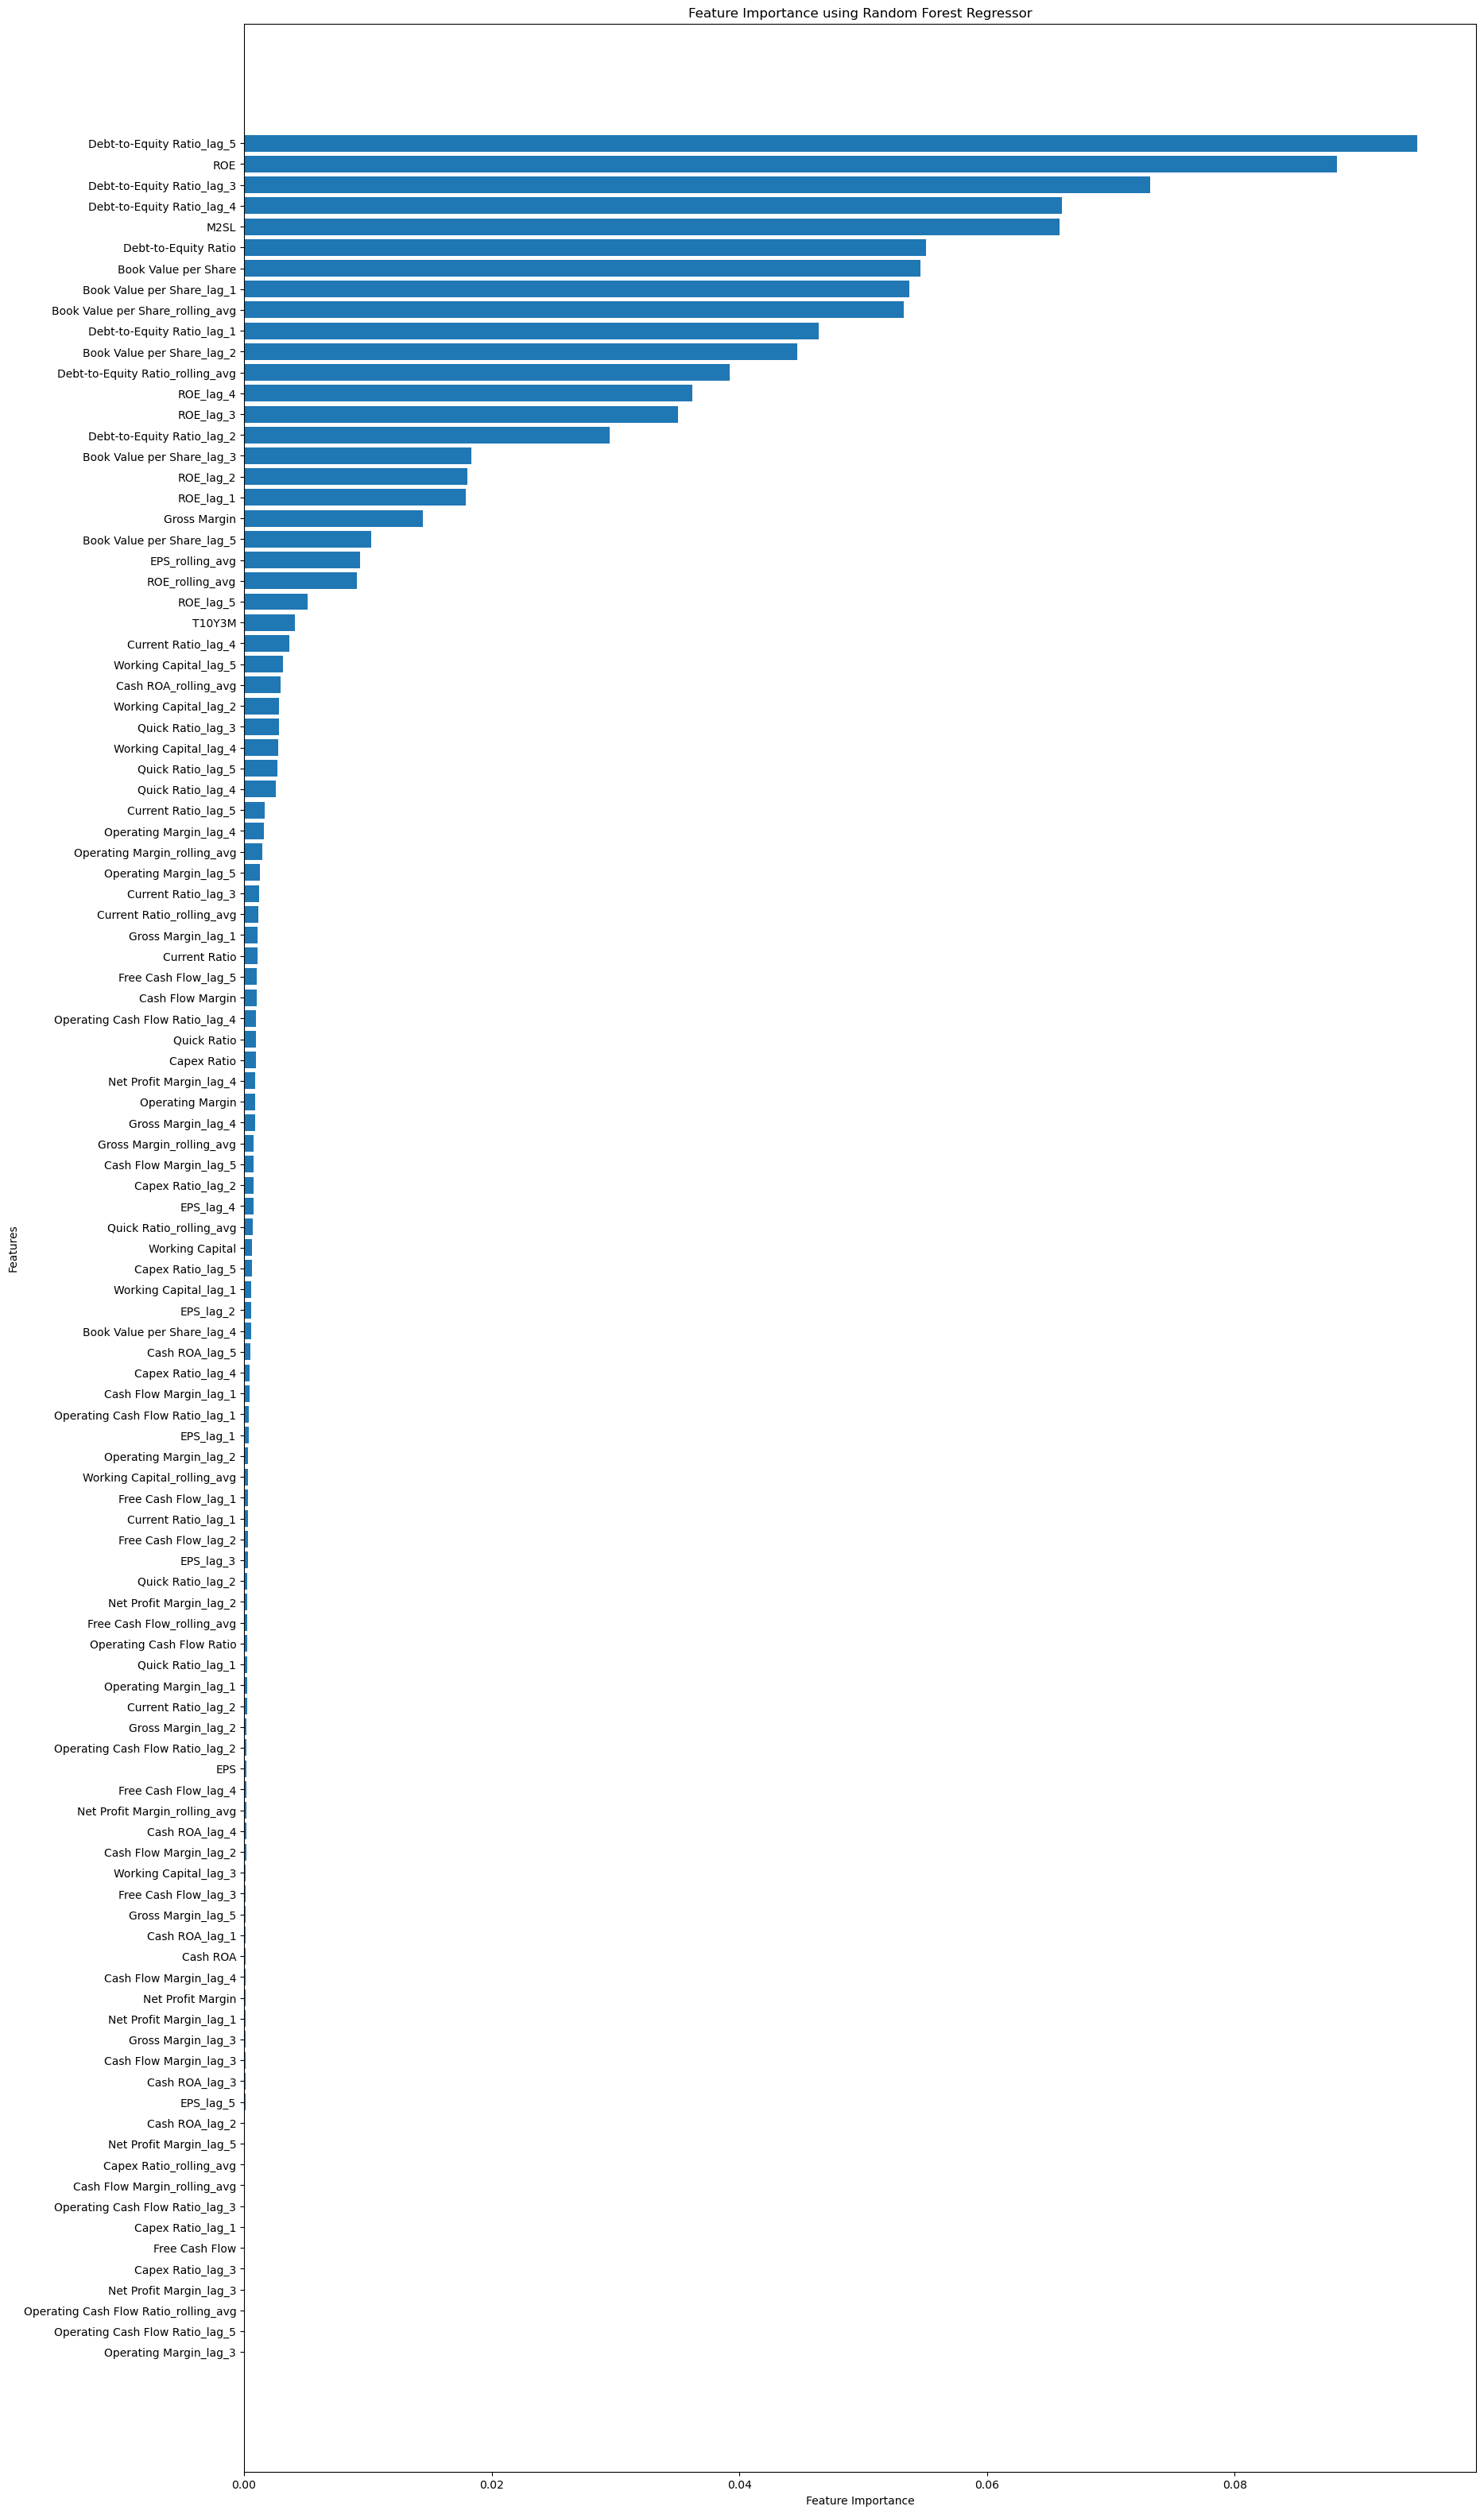

In [288]:
X = df_final.drop('Stock Price', axis=1)  # Replace 'target' with your target column name
y = df_final['Stock Price']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate feature importance
importance = model.feature_importances_

# Convert to DataFrame for better readability
importance_df_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(importance_df_rf)

# Plot feature importance
plt.figure(figsize=(20, 40))
plt.barh(importance_df_rf['Feature'], importance_df_rf['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance using Random Forest Regressor')
plt.gca().invert_yaxis()
plt.show()

In [289]:
importance_df_xgb[:20], importance_df_rf[:20]

(                          Feature  Importance
 2            Debt-to-Equity Ratio    0.608232
 44     Book Value per Share_lag_5    0.289589
 13                    Capex Ratio    0.021144
 6                    Gross Margin    0.017011
 29     Debt-to-Equity Ratio_lag_2    0.011684
 43     Book Value per Share_lag_4    0.009891
 61         Operating Margin_lag_4    0.008948
 24              Quick Ratio_lag_3    0.008341
 65                      EPS_lag_2    0.005781
 35          Working Capital_lag_2    0.005512
 0                   Current Ratio    0.004796
 81     Free Cash Flow_rolling_avg    0.002282
 40     Book Value per Share_lag_1    0.001783
 45  Net Profit Margin_rolling_avg    0.001175
 46        Net Profit Margin_lag_1    0.001150
 34          Working Capital_lag_1    0.000909
 18            Current Ratio_lag_3    0.000643
 90         Cash Flow Margin_lag_3    0.000292
 47        Net Profit Margin_lag_2    0.000275
 15      Current Ratio_rolling_avg    0.000092,
            

In [293]:
xgb_features = importance_df_xgb['Feature'].head(20)
rf_features = importance_df_rf['Feature'].head(20)

In [302]:
xgb_features

2              Debt-to-Equity Ratio
44       Book Value per Share_lag_5
13                      Capex Ratio
6                      Gross Margin
29       Debt-to-Equity Ratio_lag_2
43       Book Value per Share_lag_4
61           Operating Margin_lag_4
24                Quick Ratio_lag_3
65                        EPS_lag_2
35            Working Capital_lag_2
0                     Current Ratio
81       Free Cash Flow_rolling_avg
40       Book Value per Share_lag_1
45    Net Profit Margin_rolling_avg
46          Net Profit Margin_lag_1
34            Working Capital_lag_1
18              Current Ratio_lag_3
90           Cash Flow Margin_lag_3
47          Net Profit Margin_lag_2
15        Current Ratio_rolling_avg
Name: Feature, dtype: object

In [304]:
combined_features = xgb_features.tolist() + rf_features.tolist()
combined_features

['Debt-to-Equity Ratio',
 'Book Value per Share_lag_5',
 'Capex Ratio',
 'Gross Margin',
 'Debt-to-Equity Ratio_lag_2',
 'Book Value per Share_lag_4',
 'Operating Margin_lag_4',
 'Quick Ratio_lag_3',
 'EPS_lag_2',
 'Working Capital_lag_2',
 'Current Ratio',
 'Free Cash Flow_rolling_avg',
 'Book Value per Share_lag_1',
 'Net Profit Margin_rolling_avg',
 'Net Profit Margin_lag_1',
 'Working Capital_lag_1',
 'Current Ratio_lag_3',
 'Cash Flow Margin_lag_3',
 'Net Profit Margin_lag_2',
 'Current Ratio_rolling_avg',
 'Debt-to-Equity Ratio_lag_5',
 'ROE',
 'Debt-to-Equity Ratio_lag_3',
 'Debt-to-Equity Ratio_lag_4',
 'M2SL',
 'Debt-to-Equity Ratio',
 'Book Value per Share',
 'Book Value per Share_lag_1',
 'Book Value per Share_rolling_avg',
 'Debt-to-Equity Ratio_lag_1',
 'Book Value per Share_lag_2',
 'Debt-to-Equity Ratio_rolling_avg',
 'ROE_lag_4',
 'ROE_lag_3',
 'Debt-to-Equity Ratio_lag_2',
 'Book Value per Share_lag_3',
 'ROE_lag_2',
 'ROE_lag_1',
 'Gross Margin',
 'Book Value per Shar

In [305]:
new_features = list(set(combined_features))
new_features

['EPS_lag_2',
 'Debt-to-Equity Ratio',
 'Free Cash Flow_rolling_avg',
 'Debt-to-Equity Ratio_lag_5',
 'Debt-to-Equity Ratio_lag_4',
 'Debt-to-Equity Ratio_lag_3',
 'Working Capital_lag_2',
 'ROE_lag_4',
 'Capex Ratio',
 'ROE_lag_3',
 'Net Profit Margin_lag_2',
 'Working Capital_lag_1',
 'Cash Flow Margin_lag_3',
 'Book Value per Share_rolling_avg',
 'ROE',
 'Debt-to-Equity Ratio_rolling_avg',
 'Debt-to-Equity Ratio_lag_1',
 'Operating Margin_lag_4',
 'Current Ratio',
 'Net Profit Margin_rolling_avg',
 'M2SL',
 'Book Value per Share',
 'Net Profit Margin_lag_1',
 'Book Value per Share_lag_4',
 'Book Value per Share_lag_2',
 'ROE_lag_2',
 'Quick Ratio_lag_3',
 'Current Ratio_lag_3',
 'Book Value per Share_lag_3',
 'Current Ratio_rolling_avg',
 'Book Value per Share_lag_5',
 'ROE_lag_1',
 'Book Value per Share_lag_1',
 'Gross Margin',
 'Debt-to-Equity Ratio_lag_2']

In [306]:
new_features.append('Stock Price')
df_final = df_final[new_features]

In [307]:
df_final

,EPS_lag_2,Debt-to-Equity Ratio,Free Cash Flow_rolling_avg,Debt-to-Equity Ratio_lag_5,Debt-to-Equity Ratio_lag_4,Debt-to-Equity Ratio_lag_3,Working Capital_lag_2,ROE_lag_4,Capex Ratio,ROE_lag_3,...,Quick Ratio_lag_3,Current Ratio_lag_3,Book Value per Share_lag_3,Current Ratio_rolling_avg,Book Value per Share_lag_5,ROE_lag_1,Book Value per Share_lag_1,Gross Margin,Debt-to-Equity Ratio_lag_2,Stock Price
DATE,,,,,,,,,,,,,,,,,,,,,
2010-12-31,3.561098,0.586763,5.896000e+09,0.501296,0.507660,0.450061,2.042100e+10,9.444196,8.050247,7.812341,...,2.592035,2.644206,43.256872,2.055128,35.163155,9.014250,52.175287,38.510153,0.501357,9.739611
2011-03-31,4.703211,0.543732,6.359000e+09,0.507660,0.450061,0.501357,2.095600e+10,7.812341,9.966346,7.545638,...,2.247694,2.308032,47.194125,1.929746,39.466736,10.983061,59.352763,41.355027,0.573162,10.523166
2011-06-30,6.518750,0.539564,8.161667e+09,0.450061,0.501357,0.573162,2.013200e+10,7.545638,14.296010,9.014250,...,1.960573,2.011292,52.175287,1.841343,43.256872,9.738601,66.485047,41.727626,0.586763,10.135468
2011-09-30,6.474714,0.518906,8.236667e+09,0.501357,0.573162,0.586763,2.267000e+10,9.014250,6.339818,10.983061,...,1.808867,1.846060,59.352763,1.762135,47.194125,10.538915,74.811433,40.254687,0.543732,11.513857
2011-12-31,7.884314,0.539976,1.178267e+10,0.573162,0.586763,0.543732,2.003900e+10,10.983061,13.288418,9.738601,...,1.893657,1.931886,66.485047,1.645725,52.175287,8.644521,82.445815,44.683055,0.539564,12.228868
2012-03-31,7.127046,0.472556,1.251233e+10,0.586763,0.543732,0.539564,1.701800e+10,9.738601,9.592999,10.538915,...,1.712983,1.746081,74.811433,1.591354,59.352763,14.506851,96.602282,47.374062,0.518906,18.103260
2012-06-30,14.013950,0.457735,1.229533e+10,0.543732,0.539564,0.518906,2.016400e+10,10.538915,4.955739,8.644521,...,1.580694,1.608438,82.445815,1.578933,66.485047,11.338758,109.625640,42.811866,0.539976,17.633730
2012-09-30,12.430186,0.489417,8.776000e+09,0.539564,0.518906,0.539976,1.867600e+10,8.644521,2.639700,14.506851,...,1.546941,1.582657,96.602282,1.549997,74.811433,7.896480,119.225492,40.040594,0.472556,20.229395
2012-12-31,9.414617,0.539805,1.163900e+10,0.518906,0.539976,0.472556,1.888300e+10,14.506851,10.110488,11.338758,...,1.548570,1.582969,109.625640,1.536772,82.445815,6.956264,125.861364,38.633695,0.457735,16.211433


In [308]:
#### limited features ##### 

# df = pd.DataFrame(data, index=pd.date_range(start='2019-09-30', periods=20, freq='Q'))

# Define features and target variable
X = df_final.drop(columns=['Stock Price'])
y = df_final['Stock Price']

# Normalize the features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

# Create and train the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Display actual vs predicted values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)

Mean Squared Error: 13.17248074645896
R-squared: 0.9967623856711889
                Actual   Predicted
DATE                              
2010-12-31    9.739611   11.721406
2012-03-31   18.103260   17.386650
2019-03-31   45.654240   45.997104
2014-03-31   16.861734   15.902619
2015-09-30   24.931416   26.421024
2023-03-31  163.802307  170.728698
2019-12-31   71.332909   63.027450
2017-06-30   33.703411   35.455751
2021-12-31  175.102783  173.083631
2013-12-31   17.519619   20.238691
2024-03-31  171.247726  174.855119
2011-09-30   11.513857   13.935117


In [309]:
X = df_final.drop(columns=['Stock Price'])
y = df_final['Stock Price']

# Normalize the features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

# Create and train the XGBoost Regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_reg.fit(X_train, y_train)

# Perform cross-validation
cv_scores = cross_val_score(xgb_reg, X_normalized, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)

print(f"Cross-Validation RMSE Scores: {cv_rmse}")
print(f"Mean Cross-Validation RMSE: {cv_rmse.mean()}")

# Train the model on the training set
xgb_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = xgb_reg.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
explained_variance = explained_variance_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"Explained Variance Score: {explained_variance}")

# Display actual vs predicted values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)

Cross-Validation RMSE Scores: [14.5264123   5.99746801 15.20247937 32.34351534 29.85233644]
Mean Cross-Validation RMSE: 19.584442292238073
Mean Squared Error: 124.2604434444351
R-squared: 0.9694584945733722
Mean Absolute Error: 7.746360381444295
Root Mean Squared Error: 11.147216847466236
Mean Absolute Percentage Error: 0.181783686975843
Explained Variance Score: 0.9696915473903219
                Actual   Predicted
DATE                              
2010-12-31    9.739611   10.516719
2012-03-31   18.103260   32.649570
2019-03-31   45.654240   41.951668
2014-03-31   16.861734   18.467424
2015-09-30   24.931416   26.051487
2023-03-31  163.802307  166.504288
2019-12-31   71.332909   44.419701
2017-06-30   33.703411   29.004938
2021-12-31  175.102783  159.388412
2013-12-31   17.519619   21.922007
2024-03-31  171.247726  186.729828
2011-09-30   11.513857   10.221806


In [310]:
# Drop the target column and separate the features and target variable
X = df_final.drop(columns=['Stock Price'])
y = df_final['Stock Price']

# Normalize the features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

Window Size: 5, RMSE: 18.37696175409299
Window Size: 10, RMSE: 16.580843603564112
Window Size: 15, RMSE: 19.275568198618906
Window Size: 20, RMSE: 26.51203887084299
Window Size: 25, RMSE: 33.591604845653286
Window Size: 30, RMSE: 36.03765867546702
Window Size: 35, RMSE: 38.03887356753301
Window Size: 40, RMSE: 34.060664500237


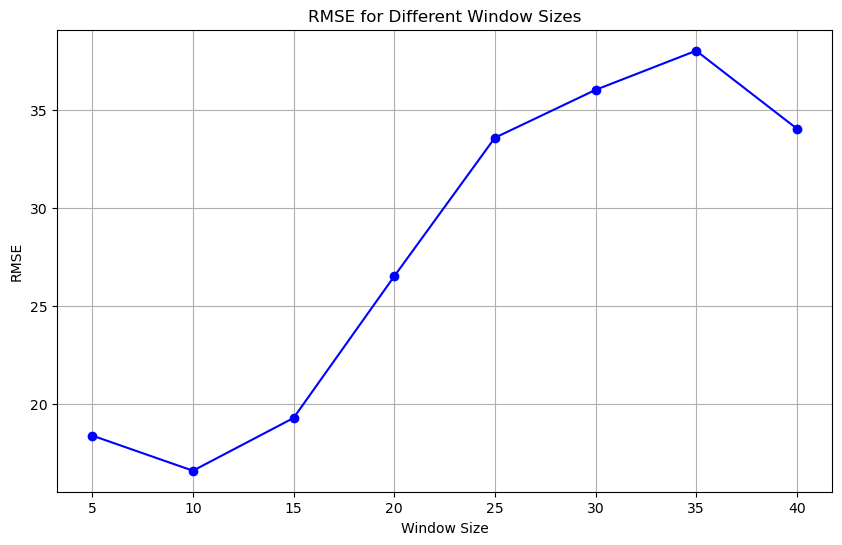

In [311]:
def rolling_backtest(window_size):
    actuals = []
    predictions = []
    dates = []

    for i in range(window_size, len(X_normalized)):
        # Define the training set
        X_train = X_normalized[i-window_size:i]
        y_train = y[i-window_size:i]
        
        # Define the test set (the next row)
        X_test = X_normalized[i].reshape(1, -1)
        y_test = y[i]
        
        # Get the date for the current test sample
        date = df.index[i]
        
        # Create and train the XGBoost Regressor
        xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
        xgb_reg.fit(X_train, y_train)
        
        # Make predictions on the test set
        y_pred = xgb_reg.predict(X_test)
        
        # Store actual, predicted values, and date
        actuals.append(y_test)
        predictions.append(y_pred[0])
        dates.append(date)

    # Calculate evaluation metrics
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    
    return rmse, actuals, predictions, dates

# Test different window sizes and find the best one
window_sizes = range(5, 45, 5)  # Test window sizes from 10 to 100 with step of 10
rmse_values = []

for window_size in window_sizes:
    rmse, actuals, predictions, dates = rolling_backtest(window_size)
    rmse_values.append(rmse)
    print(f"Window Size: {window_size}, RMSE: {rmse}")

# Plot the RMSE values for different window sizes
plt.figure(figsize=(10, 6))
plt.plot(window_sizes, rmse_values, marker='o', linestyle='-', color='b')
plt.title('RMSE for Different Window Sizes')
plt.xlabel('Window Size')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

In [312]:
best_rmse = min(rmse_values)
best_window_size = window_sizes[rmse_values.index(best_rmse)]
print(f"Best Window Size: {best_window_size} with RMSE: {best_rmse}")

Best Window Size: 10 with RMSE: 16.580843603564112


In [313]:
actuals = []
predictions = []
dates = []
signals = []
correctness = []
returns = []

# Rolling backtest
window_size = 10

for i in range(window_size, len(X_normalized)):
    # Define the training set
    X_train = X_normalized[i-window_size:i]
    y_train = y[i-window_size:i]
    
    # Define the test set (the next row)
    X_test = X_normalized[i].reshape(1, -1)
    y_test = y[i]
    
    # Get the date for the current test sample
    date = df.index[i]
    
    # Create and train the XGBoost Regressor
    xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
    xgb_reg.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = xgb_reg.predict(X_test)
    
    # Store actual, predicted values, and date
    actuals.append(y_test)
    predictions.append(y_pred[0])
    dates.append(date)
    
    # Determine the signal
    if y_pred[0] > y_test:
        signals.append('Buy')
    else:
        signals.append('Sell')
    
    # Determine correctness of the signal and calculate the return
    if i + 1 < len(y):
        next_actual = y[i + 1]
        if (signals[-1] == 'Buy' and next_actual > y[i]) or (signals[-1] == 'Sell' and next_actual < y[i]):
            correctness.append(True)
        else:
            correctness.append(False)
        
        # Calculate return based on the signal with stop loss and target
        if signals[-1] == 'Buy':
            if next_actual <= y[i] * 0.95:  # Stop loss
                returns.append(0.95)
            elif next_actual >= y[i] * 1.20:  # Target
                returns.append(1.20)
            else:
                returns.append((next_actual / y[i]))
        else:
            if next_actual >= y[i] * 1.05:  # Stop loss
                returns.append(0.95)
            elif next_actual <= y[i] * 0.80:  # Target
                returns.append(1.20)
            else:
                returns.append((y[i] / next_actual))
    else:
        correctness.append(np.nan)  # No next value to compare with
        returns.append(np.nan)  # No return to calculate

# Calculate evaluation metrics
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
mape = mean_absolute_percentage_error(actuals, predictions)
explained_variance = explained_variance_score(actuals, predictions)
correct_signals_ratio = np.nanmean(correctness)

# Print evaluation metrics
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"Explained Variance Score: {explained_variance}")
print(f"Correct Signals Ratio: {correct_signals_ratio}")

# Display actual vs predicted values with dates, buy/sell signals, correctness, and returns
results = pd.DataFrame({'Date': dates, 'Actual': actuals, 'Predicted': predictions, 'Signal': signals, 'Correctness': correctness, 'Return': returns})
results.set_index('Date', inplace=True)

# Calculate cumulative return
results['Cumulative Return'] = results['Return'].cumprod()
print(results)

Mean Squared Error: 274.92437460585296
Root Mean Squared Error: 16.580843603564112
R-squared: 0.9288922914225087
Mean Absolute Error: 10.665828932886539
Mean Absolute Percentage Error: 0.12871669994459567
Explained Variance Score: 0.9353473850439831
Correct Signals Ratio: 0.4666666666666667
                Actual   Predicted Signal Correctness    Return  \
Date                                                              
2013-06-30   12.230268   13.120428    Buy        True  1.200000   
2013-09-30   14.801604   10.877853   Sell       False  0.950000   
2013-12-31   17.519619   14.556724   Sell        True  1.039016   
2014-03-31   16.861734   15.820948   Sell       False  0.950000   
2014-06-30   20.549963   18.464502   Sell       False  0.950000   
2014-09-30   22.390051   18.050468   Sell       False  0.950000   
2014-12-31   24.636536   22.388830   Sell       False  0.950000   
2015-03-31   27.882061   24.635410   Sell       False  0.987901   
2015-06-30   28.223541   26.658091   S

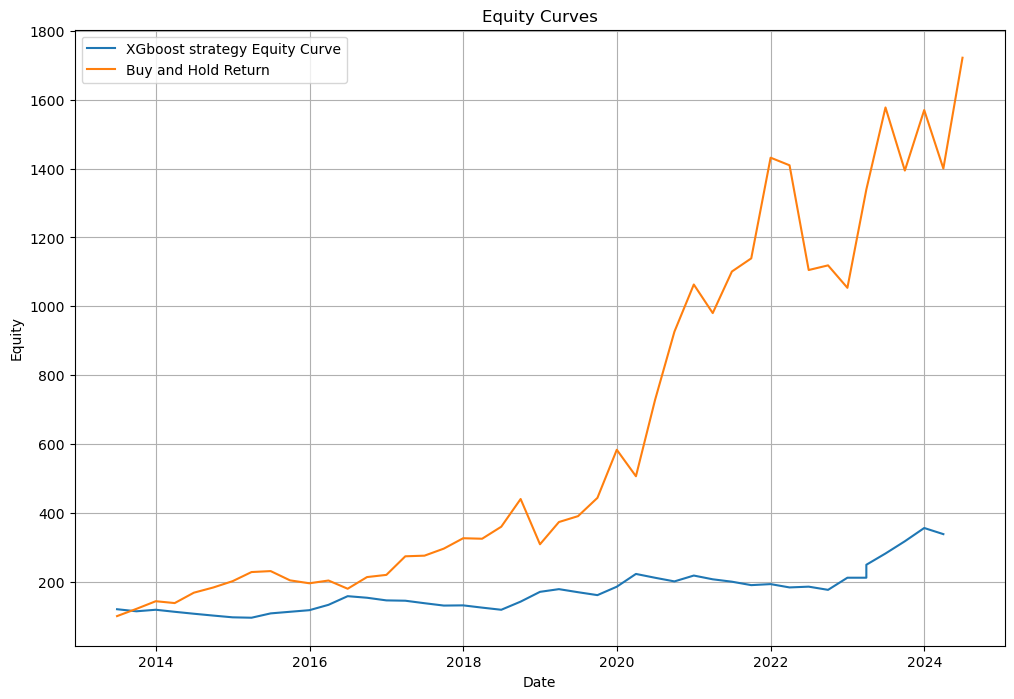

In [314]:
initial_equity = 100
results['Strategy Equity Curve'] = initial_equity * results['Return'].cumprod()

# Calculate buy and hold return starting with 100
results['Buy and Hold Return'] = initial_equity * (y[window_size:].pct_change() + 1).cumprod().fillna(1)

# Plot the equity curves
plt.figure(figsize=(12, 8))
plt.plot(results.index, results['Strategy Equity Curve'], label='XGboost strategy Equity Curve')
plt.plot(results.index, results['Buy and Hold Return'], label='Buy and Hold Return')
plt.title('Equity Curves')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.grid(True)
plt.show()

In [315]:
def calculate_metrics(equity_curve):
    returns = equity_curve.pct_change().dropna()
    mean_return = returns.mean() * 100
    std_dev = returns.std() * 100
    risk_return = mean_return/std_dev
    sharpe_ratio = mean_return / std_dev * np.sqrt(252)  # Annualized Sharpe ratio
    downside_std_dev = returns[returns < 0].std() * 100
    sortino_ratio = mean_return / downside_std_dev * np.sqrt(252)  # Annualized Sortino ratio
    
    rolling_max = equity_curve.cummax()
    drawdown = equity_curve / rolling_max - 1
    max_drawdown = drawdown.min() * 100
    
    win_streak = max(len(list(v)) for k, v in itertools.groupby((returns > 0).astype(int)) if k == 1)
    lose_streak = max(len(list(v)) for k, v in itertools.groupby((returns < 0).astype(int)) if k == 1)
    
    metrics = {
        'Mean Return': mean_return,
        'Standard Deviation': std_dev,
        'Return adjusted for risk': risk_return,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Max Drawdown': max_drawdown,
        'Winning Streak': win_streak,
        'Losing Streak': lose_streak
    }
    return metrics

strategy_metrics = calculate_metrics(results['Strategy Equity Curve'])
buy_and_hold_metrics = calculate_metrics(results['Buy and Hold Return'])

metrics_df = pd.DataFrame({
    'Strategy': strategy_metrics,
    'Buy and Hold': buy_and_hold_metrics
})

metrics_df

,Strategy,Buy and Hold
Mean Return,2.707279,7.604561
Standard Deviation,9.107469,15.108001
Return adjusted for risk,0.297259,0.503347
Sharpe Ratio,4.718844,7.990380
Sortino Ratio,34.459131,14.734543
Max Drawdown,-25.014884,-29.879325
Winning Streak,5.000000,6.000000
Losing Streak,5.000000,2.000000
